# Sequential Workflow

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [4]:
class BMIState(TypedDict):

    weight_kg: float
    heigh: float
    bmi: float
    category: str

In [5]:
def cal_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height =state['heigh']

    bmi = weight / (height**2)
    state['bmi'] = round(bmi, 2)

    return state

In [6]:
def label_bmi(state: BMIState) -> BMIState:
    if state['bmi'] < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= state['bmi'] < 24.9:
        state['category'] = 'Normal weight'
    elif 25 <= state['bmi'] < 29.9:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obese'
    return state

In [7]:
graph =StateGraph(BMIState)

graph.add_node('calculate_bmi', cal_bmi)
graph.add_node('label_bmi', label_bmi)

graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

workflow = graph.compile()

In [8]:
workflow.invoke({
    'weight_kg':80,
    'heigh': 1.73
})

{'weight_kg': 80, 'heigh': 1.73, 'bmi': 26.73, 'category': 'Overweight'}

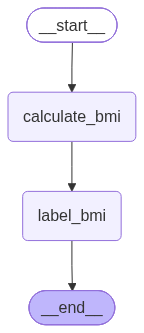

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

# LLM Workflow

In [22]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [23]:
load_dotenv()

True

In [24]:
model = ChatGroq(
    model_name="llama-3.3-70b-versatile")

In [25]:
class LLMState(TypedDict):
    question: str
    answer: str

In [26]:
def llm_qa(state: LLMState) -> LLMState:

    question = state['question']

    prompt = f"Answer the following question: {question}"

    response = model.invoke(prompt).content

    state['answer'] = response

    return state

In [28]:
graph = StateGraph(LLMState)

graph.add_node('llm_qa', llm_qa)

graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

workflow1 = graph.compile()

In [ ]:
workflow1.invoke({
    'question': "What is the capital of France?"
})


{'question': 'What is the capital of France?',
 'answer': 'The capital of France is Paris.'}

# Parallel Workflow

In [45]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

load_dotenv()

True

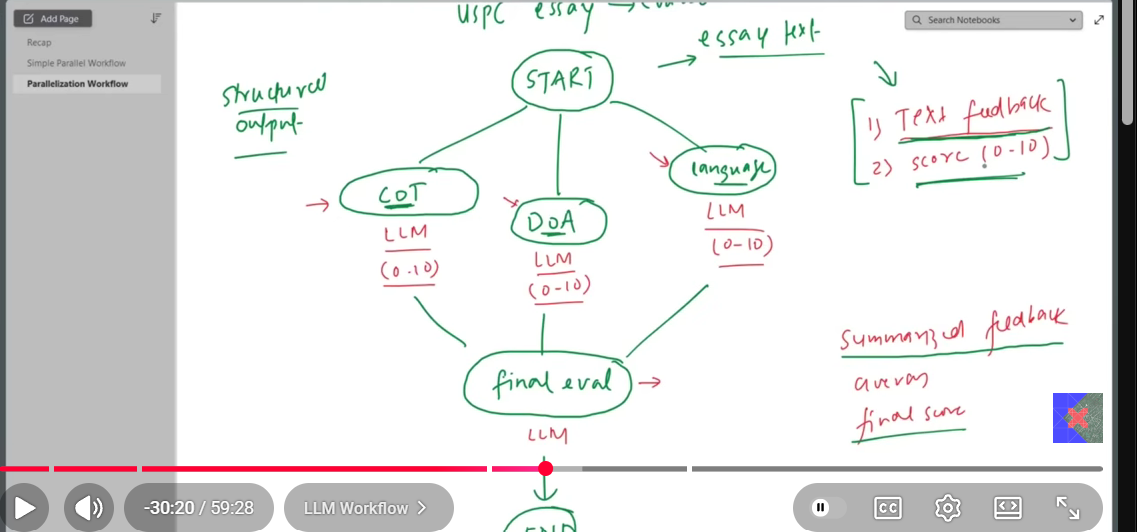

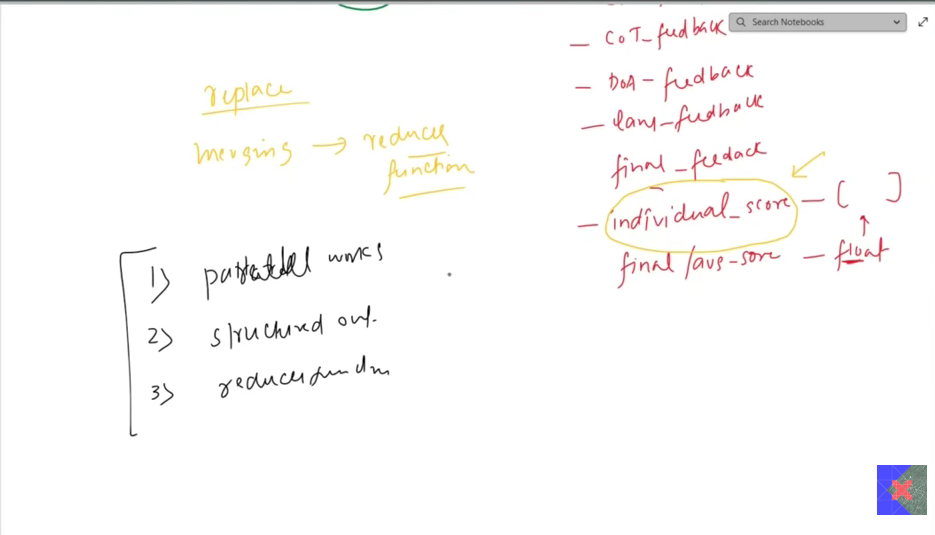

In [33]:
model = ChatGroq(
    model_name="llama-3.3-70b-versatile")

In [34]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description="Detailed feedback on the answer provided by the LLM.")
    score: int = Field(description="A score from 1 to 10 indicating the quality of the answer.", ge=1, le=10)

In [35]:
structured_model = model.with_structured_output(EvaluationSchema)

In [36]:
essay = """
The story of Artificial Intelligence (AI) is no longer a futuristic script—it is the definitive narrative of our current era. At its core, AI represents the quest to build machines capable of performing tasks that typically require human intelligence, such as reasoning, learning, problem-solving, perception, and language understanding.

From its academic origins in the mid-20th century to the massive neural networks of the 2020s, AI has transitioned from a niche engineering discipline into a foundational technology reshaping global society.

1. The Core Architecture: From Rules to Learning
To understand AI, it helps to look at its structural evolution. Early AI relied heavily on Expert Systems—programs built on rigid, human-coded rules (e.g., "If X and Y, then do Z"). While effective for narrow tasks like chess, these systems lacked adaptability.

The true breakthrough came with Machine Learning (ML), a paradigm shift where instead of programming specific instructions, engineers feed algorithms massive datasets and let the system discover the underlying patterns itself.


2. Real-World Applications
AI is no longer confined to data centers; it serves as an invisible infrastructure across multiple verticals:

Healthcare: AI algorithms analyze medical imagery (X-rays, MRIs) with accuracy rates that rival top radiologists. In genomics and pharmacology, AI models compress the timeline for drug discovery from a decade down to months by predicting how proteins fold and interact.

Finance & Decision Intelligence: Financial institutions deploy machine learning pipelines for real-time fraud detection, algorithmic trading, and credit risk assessment. Furthermore, cities and logistics companies utilize AI for predictive analytics—such as forecasting public transit and taxi demand based on weather, time, and historical lag features—to optimize fleet allocation.

Data Analytics & Visualization: Tools powered by AI automatically parse massive, messy datasets, allowing developers and business analysts to build dynamic dashboards (like in Power BI) that can predict future trends, automate reporting, and surface anomalies without manual scripting.

Computer Vision: From autonomous vehicles navigating complex traffic to industrial deep learning pipelines designed for automated object recognition (like automated toll collection via number plate detection), vision models allow machines to interpret and react to the physical world accurately.

3. The Dual Horizons: Narrow AI vs. AGI
When discussing the future of AI, it is crucial to categorize its capabilities into two distinct horizons:

Artificial Narrow Intelligence (ANI)
This is the AI we interact with today. ANI excels at a specific, predefined task—whether that is generating text, driving a car, or playing a specific video game. However, a state-of-the-art medical diagnosis AI cannot write a line of code or compose a song; its intelligence is highly specialized and non-transferable.

Artificial General Intelligence (AGI)
AGI represents a theoretical inflection point: an autonomous system that matches or surpasses human capabilities across a broad spectrum of cognitive tasks. An AGI would possess the capacity to learn, reason, abstract, and apply knowledge dynamically across unrelated fields without explicit retraining. While the exact timeline to achieve true AGI remains highly debated among researchers, current engineering focuses heavily on multi-modal models (systems that process text, code, audio, and vision simultaneously) as stepping stones toward this goal.

4. The Ethical and Socioeconomic Imperative
As AI scales, it brings deep systemic challenges that society must actively address:

Algorithmic Bias: Because AI models learn from historical human data, they frequently inherit and amplify existing societal biases. If a recruitment or judicial AI is trained on historical data reflecting systemic prejudice, the model will replicate those exact disparities under the guise of mathematical objectivity. Mitigating bias requires rigorous data curation and algorithmic auditing.

The Black Box Problem: Many deep learning models are so complex that even their creators cannot fully trace why a specific decision was reached. This lack of interpretability poses severe risks in high-stakes fields like medicine and criminal justice.

Economic Disruption: AI is systematically altering the labor landscape. While it automates repetitive engineering, writing, and administrative tasks, it also creates an intense demand for new roles, such as prompt engineers, data curation specialists, and AI ethics auditors. The challenge lies in managing this massive workforce transition through proactive upskilling.

Conclusion
Artificial Intelligence is far more than a collection of code; it is a profound extension of human capability. It offers unprecedented tools to tackle humanity's most complex challenges—from decoding diseases to optimizing global resources.

However, the trajectory of AI will ultimately be determined not just by the sophistication of its algorithms, but by the ethical frameworks, transparency standards, and human guardrails we build around it. The goal is not merely to create machines that think, but to build technology that fundamentally elevates and empowers human potential.
"""

In [43]:
prompt = f'Evaluate the following essay and provide feedback and a score from 1 to 10:\n\n{essay}'
structured_model.invoke(prompt)

print(structured_model.invoke(prompt).feedback)
print(structured_model.invoke(prompt).score)

The essay provides a comprehensive overview of Artificial Intelligence, covering its evolution, core architecture, real-world applications, and the distinction between Narrow AI and General AI. The author demonstrates a deep understanding of the subject matter, including the technical aspects of AI and its societal implications. The writing is clear, well-structured, and engaging, making the complex topic accessible to a broad audience. The inclusion of specific examples and applications of AI in various fields adds depth and concreteness to the discussion. The author also addresses the critical ethical and socioeconomic challenges associated with AI, such as algorithmic bias, the black box problem, and economic disruption, highlighting the need for ethical frameworks and human oversight. The conclusion effectively synthesizes the main points and emphasizes the importance of ensuring that AI development aligns with human values and promotes empowerment. The only area for improvement co

In [46]:
class UPSCState(TypedDict):

    essay: str
    lang_feed: str
    anal_feed: str
    clar_feed: str

    over_feed: str
    individual_scores: Annotated[list[int], operator.add]  # reducers -> instead of overwrite
    avg_score: float

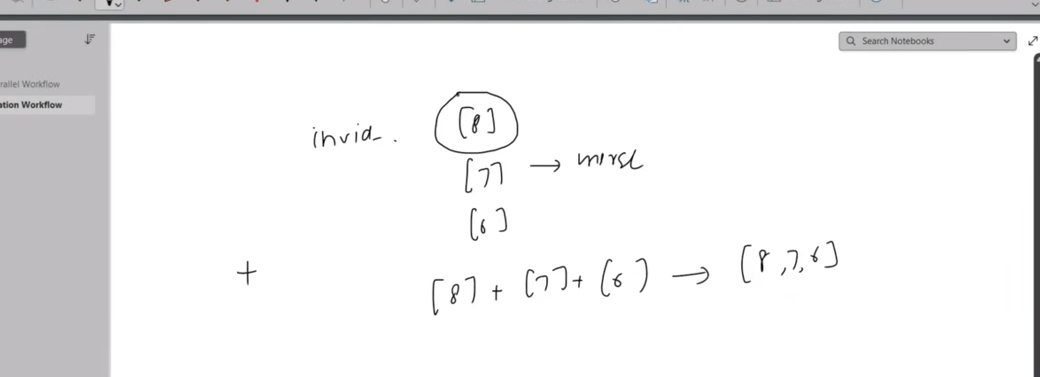

In [ ]:
def evaluate_language(state: UPSCState) -> UPSCState:

    prompt = f'Evaluate the following essay for language quality and provide feedback and a score from 1 to 10:\n{state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'lang_feed': output.feedback, 'individual_scores': [output.score]}


In [ ]:
def evaluate_analysis(state: UPSCState) -> UPSCState:

    prompt = f'Evaluate the following essay for language quality and provide feedback and a score from 1 to 10:\n{state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'lang_feed': output.feedback, 'individual_scores': [output.score]}


In [ ]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_eval', final_eval)

NameError: name 'evaluate_language' is not defined

# Conditional Workflow

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field


In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model_name="llama-3.3-70b-versatile")

In [4]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive","negative"] = Field(description='Sentiment of the review')

In [7]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal['UX','Performance', 'Bug', 'Support', 'Other'] = Field(description='Type of issue reported by the user')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [9]:
structured_model1 = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [10]:
prompt = 'What is the sentiment of the following review - The software too good'
structured_model1.invoke(prompt)

SentimentSchema(sentiment='positive')

In [11]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative', 'neutral']
    diagnosis: dict
    response: str

In [28]:
def find_sentiment(state: ReviewState) -> ReviewState:

    prompt = f'For the following review, determine the sentiment (positive, negative, neutral) and provide a diagnosis of the issue type, tone, and urgency if applicable:\n\nReview: {state["review"]}'
    res = structured_model1.invoke(prompt)
    return {'sentiment': res}

def check_sentiment(state: ReviewState) -> Literal['positive_response', 'run_diagnosis', 'neutral_response']:

    if state['sentiment'] == 'positive':
        return 'positive_respnse'
    elif state['sentiment'] == 'negative':
        return 'run_diagnosis'
    else:
        return 'neutral_response'

def positive_response(state: ReviewState) -> ReviewState:

    prompt = f'Write a warm thank you response to the following positive review:\n\nReview: {state["review"]}'
    res = model.invoke(prompt).content
    return {'resonse': res}

def neutral_response(state: ReviewState) -> ReviewState:

    prompt = f'Warning: The following review is neutral. Write a polite response acknowledging the feedback and asking for more details if possible:\n\nReview: {state["review"]}'
    res = model.invoke(prompt).content
    return {'response': res}

def run_diagnosis(state: ReviewState) -> ReviewState:

    prompt = f'For the following negative review, provide a diagnosis of the issue type, tone, and urgency:\n\nReview: {state["review"]}'
    res = structured_model2.invoke(prompt)
    return {'diagnosis': res.model_dump}

def negative_response(state: ReviewState) -> ReviewState:

    prompt = f'Write a professional and empathetic response to the following negative review, addressing the issue type, tone, and urgency as diagnosed:\n\nReview: {state["review"]}\nDiagnosis: {state["diagnosis"]}'
    res = model.invoke(prompt).content
    return {'response': res}

In [29]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('positive_response', positive_response)
graph.add_node('neutral_response', neutral_response)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('neutral_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

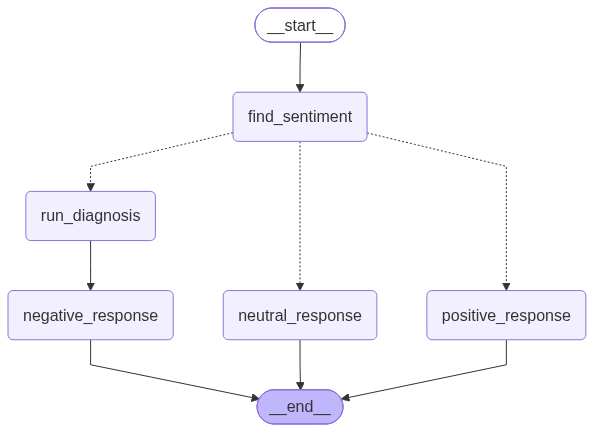

In [30]:
workflow = graph.compile()
workflow

In [31]:
initial = {
    'review' : "In my experience, the software has been incredibly intuitive and user-friendly. It has significantly improved my productivity and I would highly recommend it to others. But I did encounter a few minor bugs that caused some frustration. Overall, it's a great product, but there's room for improvement in terms of stability and performance."
}
workflow.invoke(initial)

{'review': "In my experience, the software has been incredibly intuitive and user-friendly. It has significantly improved my productivity and I would highly recommend it to others. But I did encounter a few minor bugs that caused some frustration. Overall, it's a great product, but there's room for improvement in terms of stability and performance.",
 'sentiment': SentimentSchema(sentiment='positive'),
 'response': "Dear valued customer,\n\nThank you for taking the time to share your honest feedback about our software. We're thrilled to hear that you've found it intuitive and user-friendly, and that it has had a positive impact on your productivity. We appreciate your recommendation and are glad that our product has been able to meet your needs in many ways.\n\nHowever, we're sorry to hear that you encountered some minor bugs that caused frustration. We take all feedback seriously and would like to learn more about the issues you experienced. If you're willing, could you please provide

# Iterative Workflow

In [15]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator
load_dotenv

<function dotenv.main.load_dotenv(dotenv_path: Union[str, ForwardRef('os.PathLike[str]'), NoneType] = None, stream: Optional[IO[str]] = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: Optional[str] = 'utf-8') -> bool>

In [27]:
generator_llm = ChatGroq(model_name="llama-3.3-70b-versatile")
evaluator_llm = ChatGroq(model_name="llama-3.3-70b-versatile")
optimizer_llm = ChatGroq(model_name="llama-3.3-70b-versatile")

In [28]:
class TweetEvaluationSchema(BaseModel):
    evaluation: Literal['approved', 'needs_improvement'] = Field(description='Evaluation of the tweet based on content, tone, and relevance.')
    feedback: str = Field(description='Constructive feedback for improving the tweet.')

In [29]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluationSchema)

In [30]:
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal['approved', 'needs_improvement']
    feedback: str

    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [31]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [32]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [33]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [34]:
def route_evaluation(state: TweetState) -> Literal['approved', 'needs_improvement']:

    if state['evaluation'] == 'approved':
        return 'approved'
    else:
        return 'needs_improvement'

In [35]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
# graph.add_node('approved', approved_tweet)
# graph.add_node('needs_improvement', needs_improvement)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'need_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')


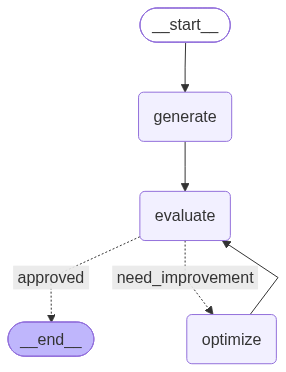

In [36]:
workflow = graph.compile()

workflow

In [39]:
initial_state = {
    "topic": "Modi Melody Melony",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [40]:
result

{'topic': 'Modi Melody Melony',
 'tweet': '"Just listened to Modi Melody Melony and I\'m pretty sure my plants are now demanding a 5-day workweek and a chai break" #ModiMelodyMelony',
 'evaluation': 'approved',
 'feedback': "This tweet is a breath of fresh air, with a unique and quirky observation that's both humorous and relatable. The use of the hashtag #ModiMelodyMelony adds a touch of cleverness, and the tweet's format is well-crafted, making it easy to read and understand. The punchline about plants demanding a 5-day workweek and a chai break is unexpected and amusing, making it scroll-stopping and potentially viral. Overall, this tweet checks all the right boxes, with a great balance of originality, humor, and punchiness, making it an 'approved' tweet.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['"Just listened to Modi Melody Melony and I\'m pretty sure my plants are now demanding a 5-day workweek and a chai break" #ModiMelodyMelony'],
 'feedback_history': ["This t

In [51]:
a = f'What is Modi Meloni meme on Instagram?'
res = generator_llm.invoke(a)
res.content

'The "Modi Meloni" meme is a humorous trend that originated on social media platforms, particularly Instagram and Twitter. It involves photoshopping or editing images of Indian Prime Minister Narendra Modi and Italian Prime Minister Giorgia Meloni into various scenarios, often with comedic or satirical intentions.\n\nThe meme typically features the two leaders in unexpected or absurd situations, such as:\n\n1. Sharing a plate of food or drinks.\n2. Engaging in a fun activity, like playing a sport or musical instrument.\n3. Wearing ridiculous outfits or accessories.\n4. Interacting with other famous personalities or fictional characters.\n\nThe "Modi Meloni" meme is often used to poke fun at politics, international relations, or current events, but it can also be seen as a lighthearted way to humanize world leaders and bring some humor to the news.\n\nKeep in mind that memes can be subjective and may not be to everyone\'s taste. If you\'re interested in exploring more, you can search fo

# Persistance (Memory)

In [17]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [18]:
load_dotenv()

llm = ChatGroq(model_name="llama-3.3-70b-versatile")

In [19]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [20]:
def generate_joke(state: JokeState) -> JokeState:

    prompt = f"Generate a short, funny joke on the topic: '{state['topic']}"
    response = llm.invoke(prompt).content
    return {'joke': response}

def explain_joke(state: JokeState) -> JokeState:

    prompt = f"Explain the joke: '{state['joke']}' in simple terms."
    response = llm.invoke(prompt).content
    return {'explanation': response}

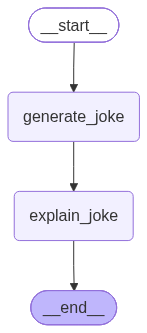

In [21]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('explain_joke', explain_joke)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'explain_joke')
graph.add_edge('explain_joke', END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [22]:
config1 = {
    "configurable": {"thread_id": "1"}
}
workflow.invoke({"topic": "pizza"}, config=config1)

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty!',
 'explanation': 'This joke is funny because it\'s a play on words. "Crusty" has two meanings:\n\n1. A pizza has a crust, which is the outer layer of the bread.\n2. When someone is "feeling crusty", it means they\'re in a bad mood or being grumpy.\n\nThe joke is saying that the pizza is in a bad mood because it\'s "feeling crusty", but it\'s also a reference to the fact that pizzas have a crust. It\'s a clever and silly pun that creates the humor!'}

In [23]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty!', 'explanation': 'This joke is funny because it\'s a play on words. "Crusty" has two meanings:\n\n1. A pizza has a crust, which is the outer layer of the bread.\n2. When someone is "feeling crusty", it means they\'re in a bad mood or being grumpy.\n\nThe joke is saying that the pizza is in a bad mood because it\'s "feeling crusty", but it\'s also a reference to the fact that pizzas have a crust. It\'s a clever and silly pun that creates the humor!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18b475-75af-6dd2-8002-7b514a02df14'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-29T12:16:34.971551+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18b475-7171-6710-8001-c237096c666e'}}, tasks=(), interrupts=())

In [24]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty!', 'explanation': 'This joke is funny because it\'s a play on words. "Crusty" has two meanings:\n\n1. A pizza has a crust, which is the outer layer of the bread.\n2. When someone is "feeling crusty", it means they\'re in a bad mood or being grumpy.\n\nThe joke is saying that the pizza is in a bad mood because it\'s "feeling crusty", but it\'s also a reference to the fact that pizzas have a crust. It\'s a clever and silly pun that creates the humor!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18b475-75af-6dd2-8002-7b514a02df14'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-29T12:16:34.971551+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18b475-7171-6710-8001-c237096c666e'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 

In [28]:
config2 = {
    "configurable": {"thread_id": "2"}
}
workflow.invoke({"topic": "Narenda Modi"}, config=config1)

{'topic': 'Narenda Modi',
 'joke': 'Why did Narendra Modi bring a ladder to the meeting?\n\nBecause he wanted to take his "Make in India" initiative to the next level! (get it?)',
 'explanation': 'The joke is a play on words. "Take it to the next level" is a common phrase that means to improve or advance something. But in this joke, "next level" has a double meaning:\n\n1. Improve the "Make in India" initiative (the usual meaning).\n2. Literally go up to a higher level, using a ladder (the funny part).\n\nSo, the joke is saying that Narendra Modi brought a ladder to the meeting because he wanted to improve his initiative, but also because "next level" sounds like he\'s going up a physical level, like a staircase. It\'s a lighthearted and humorous way to make a pun on the phrase.'}

In [30]:
workflow.get_state(config2)

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '2'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [31]:
list(workflow.get_state_history(config2))

[]

In [32]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": '1f18b475-7171-6710-8001-c237096c666e'}})

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty!'}, next=('explain_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f18b475-7171-6710-8001-c237096c666e'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-29T12:16:34.526566+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18b475-6a84-6d71-8000-5a9e51eaa810'}}, tasks=(PregelTask(id='9d298af4-38cc-46c6-d43a-dee8707ed79d', name='explain_joke', path=('__pregel_pull', 'explain_joke'), error=None, interrupts=(), state=None, result={'explanation': 'This joke is funny because it\'s a play on words. "Crusty" has two meanings:\n\n1. A pizza has a crust, which is the outer layer of the bread.\n2. When someone is "feeling crusty", it means they\'re in a bad mood or being grumpy.\n\nThe joke is saying that the pizza is in a bad mood because it\'s "feeling crusty", but it\'s also a

In [33]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": '1f18b475-7171-6710-8001-c237096c666e'}})

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty!',
 'explanation': 'This joke is a play on words. \n\nThe word "crusty" has two meanings:\n1. It can describe the outer layer of a pizza, which is crispy and hard (the crust).\n2. It can also mean being grumpy or irritable (in a bad mood).\n\nThe joke is funny because it uses the word "crusty" to make a connection between the pizza\'s crust (the food) and its mood (being grumpy). It\'s a clever and silly way to make a joke about a pizza being in a bad mood.'}

In [34]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty!', 'explanation': 'This joke is a play on words. \n\nThe word "crusty" has two meanings:\n1. It can describe the outer layer of a pizza, which is crispy and hard (the crust).\n2. It can also mean being grumpy or irritable (in a bad mood).\n\nThe joke is funny because it uses the word "crusty" to make a connection between the pizza\'s crust (the food) and its mood (being grumpy). It\'s a clever and silly way to make a joke about a pizza being in a bad mood.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18b47c-f68f-605d-8003-8e09d5025b35'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-07-29T12:19:56.389556+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18b47c-e950-6a5a-8002-e71baf52bffe'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'

In [37]:
# Updating State
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f18b475-7171-6710-8001-c237096c666e", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18b482-2bc9-65df-8002-3b608234e04e'}}

In [38]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty!'}, next=('explain_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18b482-2bc9-65df-8002-3b608234e04e'}}, metadata={'source': 'update', 'step': 2, 'parents': {}}, created_at='2026-07-29T12:22:16.188636+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18b475-7171-6710-8001-c237096c666e'}}, tasks=(PregelTask(id='d3827d6c-a657-1087-c83c-95ab7551998c', name='explain_joke', path=('__pregel_pull', 'explain_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'samosa', 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty!', 'explanation': 'This joke is a play on words. \n\nThe word "crusty" has two meanings:\n1. It can describe the outer layer of a pizza, which is crispy and hard (the crust).\n

In [39]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f18b475-7171-6710-8001-c237096c666e"}})

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood? Because it was feeling a little crusty!',
 'explanation': 'This joke is a play on words. \n\n"Pizza" has a "crust" (the hard outer part of the pizza). \nBut "crusty" also means being in a bad mood or being grumpy. \n\nSo, the joke is saying the pizza is in a bad mood (feeling crusty), but it\'s also referencing the fact that pizza has a crust. It\'s a funny way of using a word that has two different meanings.'}

# Fault Tolerance

In [40]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [41]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [42]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [43]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)


In [1]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...


NameError: name 'graph' is not defined

In [ ]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

# Tools